# Kế Hoạch Thực Tập: AI Y Tế Đa Phương Thức (9 Notebooks Pipeline)
## Notebook 5.1: TransMIL Ablation Study (Khắc phục Lỗi Không Gian)

**Tại sao phải có bản Ablation (Cắt bỏ) này?**
Ở Notebook 5, phiên bản TransMIL Official gốc đã rớt đài thảm hại (F1 ~0.39). Phân tích chuyên sâu cho thấy:
1. Lõi **PPEG** của TransMIL sử dụng mảng Conv2D để quy hoạch lại không gian tế bào.
2. Nhưng dữ liệu `.pt` của chúng ta là các vector rời rạc, **KHÔNG CÓ** tọa độ X, Y. Các tế bào đứng cạnh nhau trong mảng chưa chắc đã nằm cạnh nhau ngoài đời thực.
3. Việc cố tình chạy PPEG đã ép các tế bào xa lạ trở thành "hàng xóm", vô tình biến PPEG thành một cỗ máy tạo nhiễu (Noise Generator) hủy diệt nhận thức của Transformer.

**Nhiệm vụ của Notebook 5.1:**
- Thực hiện **Ablation Study (Nghiên cứu Cắt bỏ)**: Gỡ bỏ hoàn toàn module PPEG. Biến TransMIL thành một mô hình Vô hướng (Order-invariant).
- Vẫn giữ lại trái tim **Nyströmformer** để xử lý hàng vạn tế bào cùng lúc.
- Vẫn giữ lại cơ chế **[CLS] Token** để hút tín hiệu ung thư.
- Thay vũ khí tối tân: Dùng **`torch.optim.RAdam`** (Rectified Adam) kết hợp **Gradient Accumulation** và **Label Smoothing** để ép Transformer hội tụ chính xác.

In [1]:
!pip install nystrom-attention

In [2]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from nystrom_attention import NystromAttention

import warnings
warnings.filterwarnings('ignore')

In [3]:
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files' 
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

df = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df.columns) < 5:
    df = pd.read_csv(CLINICAL_CSV)

valid_subtypes = ['BRCA_LumA', 'BRCA_LumB', 'BRCA_Basal', 'BRCA_Her2']
df_filtered = df[df['pam50_subtype'].isin(valid_subtypes)].copy()
label_map = {'BRCA_LumA': 0, 'BRCA_LumB': 1, 'BRCA_Basal': 2, 'BRCA_Her2': 3}
df_filtered['label'] = df_filtered['pam50_subtype'].map(label_map)
patient_label_dict = dict(zip(df_filtered['patientId'], df_filtered['label']))

class MILBagDataset(Dataset):
    def __init__(self, patient_ids, pt_dir, label_dict):
        self.patient_ids = patient_ids
        self.pt_dir = pt_dir
        self.label_dict = label_dict
        
    def __len__(self):
        return len(self.patient_ids)
        
    def __getitem__(self, idx):
        pid = self.patient_ids[idx]
        pt_path = os.path.join(self.pt_dir, f"{pid}.pt")
        features = torch.load(pt_path, map_location='cpu') # Shape: [N, 2048]
        label = self.label_dict[pid]
        return features, label, pid

if os.path.exists(PT_DIR):
    valid_pids = [p for p in df_filtered['patientId'].tolist() if os.path.exists(os.path.join(PT_DIR, f"{p}.pt"))]
    labels = [patient_label_dict[pid] for pid in valid_pids]
    print(f"Tìm thấy {len(valid_pids)} bệnh nhân hợp lệ.")
else:
    print("Lỗi: Không tìm thấy thư mục PT_DIR.")
    valid_pids, labels = [], []

Tìm thấy 882 bệnh nhân hợp lệ.


### 2. Mô Hình TransMIL (Bản Cắt Bỏ PPEG - Vô Hướng)
Lưu ý: Bạn sẽ thấy module PPEG bị gạch bỏ hoàn toàn khỏi luồng `forward`. Không còn việc ép chuỗi thành lưới vuông `_H x _W` nữa!

In [4]:
class TransLayer(nn.Module):
    def __init__(self, norm_layer=nn.LayerNorm, dim=512):
        super().__init__()
        self.norm = norm_layer(dim)
        self.attn = NystromAttention(
            dim = dim,
            dim_head = dim//8,
            heads = 8,
            num_landmarks = dim//2,    
            pinv_iterations = 6,    
            residual = True,         
            dropout=0.1
        )

    def forward(self, x):
        x = x + self.attn(self.norm(x))
        return x

class TransMIL_Ablation(nn.Module):
    def __init__(self, input_dim=2048, n_classes=4):
        super(TransMIL_Ablation, self).__init__()
        
        # Nén từ 2048 xuống 512
        self._fc1 = nn.Sequential(nn.Linear(input_dim, 512), nn.ReLU())
        
        # Gián điệp CLS Token hút thông tin ung thư
        self.cls_token = nn.Parameter(torch.randn(1, 1, 512))
        self.n_classes = n_classes
        
        # 2 Lớp Nyströmformer tốc độ cao
        self.layer1 = TransLayer(dim=512)
        self.layer2 = TransLayer(dim=512)
        
        self.norm = nn.LayerNorm(512)
        self._fc2 = nn.Linear(512, self.n_classes)

    def forward(self, x):
        # x: [1, N, 2048]
        h = x.float()
        h = self._fc1(h) # [1, N, 512]
        
        # ----> [ĐÃ CẮT BỎ] KHÔNG ép thành hình vuông _H x _W
        # ----> [ĐÃ CẮT BỎ] KHÔNG dùng PPEG Convolution gây nhiễu

        # ----> Thêm [CLS] Token
        B = h.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        h = torch.cat((cls_tokens, h), dim=1) # [1, N + 1, 512]

        # ----> Nyström Attention Layer 1
        h = self.layer1(h) 
        
        # ----> Nyström Attention Layer 2
        h = self.layer2(h) 

        # ----> Gom kết quả từ [CLS] Token
        h = self.norm(h)[:,0]

        # ----> Phân loại
        logits = self._fc2(h) # [1, 4]
        return logits, None

### 3. Vòng Lặp Huấn Luyện Trang Bị "Tận Răng" (RAdam + Accumulation)
Để trị căn bệnh "say sóng" của Transformer, ta dùng 3 liều thuốc mạnh:
1. **RAdam (Rectified Adam):** Kìm hãm sự hưng phấn quá đà ở những epoch đầu tiên.
2. **Gradient Accumulation = 16:** Đọc 16 bệnh nhân mới cập nhật trọng số 1 lần.
3. **Label Smoothing = 0.1:** Cấm mô hình không được tin tưởng 100% vào nhãn đa số.

In [5]:
if len(valid_pids) > 0:
    class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    
    # Thuốc 1: Label Smoothing
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    epochs = 30 # Kéo dài thời gian train vì RAdam học khá chậm và chắc
    batch_size = 1 
    # Thuốc 2: Gradient Accumulation
    accumulation_steps = 16 
    
    fold_results = []
    best_global_preds = []
    best_global_labels = []

    print(f"Khởi động lò nung TransMIL Ablation trên thiết bị: {device}")
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(valid_pids, labels)):
        print(f"\n--- Bắt đầu Fold {fold + 1}/5 ---")
        
        train_pids = [valid_pids[i] for i in train_idx]
        test_pids = [valid_pids[i] for i in test_idx]
        
        train_dataset = MILBagDataset(train_pids, PT_DIR, patient_label_dict)
        test_dataset = MILBagDataset(test_pids, PT_DIR, patient_label_dict)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        model = TransMIL_Ablation(input_dim=2048, n_classes=4).to(device)
        
        # Thuốc 3: RAdam siêu hội tụ
        optimizer = optim.RAdam(model.parameters(), lr=5e-4, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
        
        best_f1 = 0.0
        best_acc = 0.0
        fold_preds = []
        fold_labels = []
        
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            
            for step, (features, label, _) in enumerate(train_loader):
                features, label = features.to(device), label.to(device)
                
                logits, _ = model(features)
                loss = criterion(logits, label)
                loss = loss / accumulation_steps 
                loss.backward()
                
                if (step + 1) % accumulation_steps == 0 or (step + 1) == len(train_loader):
                    optimizer.step()
                    optimizer.zero_grad()
            
            scheduler.step()
            
            model.eval()
            epoch_preds = []
            epoch_labels = []
            with torch.no_grad():
                for features, label, _ in test_loader:
                    features, label = features.to(device), label.to(device)
                    logits, _ = model(features)
                    _, pred = torch.max(logits, 1)
                    epoch_preds.extend(pred.cpu().numpy())
                    epoch_labels.extend(label.cpu().numpy())
            
            val_acc = accuracy_score(epoch_labels, epoch_preds)
            val_f1 = f1_score(epoch_labels, epoch_preds, average='macro')
            
            if val_f1 > best_f1:
                best_f1 = val_f1
                best_acc = val_acc
                fold_preds = epoch_preds
                fold_labels = epoch_labels
                torch.save(model.state_dict(), f"/kaggle/working/transmil_ablation_fold{fold+1}_best.pth")
                
        print(f"Fold {fold+1} Kỷ lục mới - Accuracy: {best_acc:.4f} | Macro-F1: {best_f1:.4f}")
        fold_results.append((best_acc, best_f1))
        best_global_preds.extend(fold_preds)
        best_global_labels.extend(fold_labels)
    
    mean_acc = np.mean([x[0] for x in fold_results])
    std_acc = np.std([x[0] for x in fold_results])
    mean_f1 = np.mean([x[1] for x in fold_results])
    std_f1 = np.std([x[1] for x in fold_results])
    
    print("\n=======================================================")
    print(" TỔNG KẾT TRANSMIL ABLATION STUDY (5-FOLD)")
    print("=======================================================")
    print(f"🎯 Khôi phục phong độ: Accuracy: {mean_acc:.4f} ˙ {std_acc:.4f}")
    print(f"⚖️ Giới hạn F1: Macro-F1: {mean_f1:.4f} ˙ {std_f1:.4f}")
    print("=======================================================")

    # Xuất bảng metrics 5-Fold để phục vụ so sánh
    df_metrics = pd.DataFrame(fold_results, columns=["Accuracy", "Macro_F1"])
    df_metrics.to_csv("/kaggle/working/transmil_ablation_5fold_metrics.csv", index=False)
    print("✓ Đã lưu trọng số Ablation 5-Fold (.pth) và bảng điểm (.csv) vào /kaggle/working/")

Khởi động lò nung TransMIL Ablation trên thiết bị: cuda

--- Bắt đầu Fold 1/5 ---
Fold 1 Kỷ lục mới - Accuracy: 0.5876 | Macro-F1: 0.4261

--- Bắt đầu Fold 2/5 ---
Fold 2 Kỷ lục mới - Accuracy: 0.5424 | Macro-F1: 0.4832

--- Bắt đầu Fold 3/5 ---
Fold 3 Kỷ lục mới - Accuracy: 0.6080 | Macro-F1: 0.4308

--- Bắt đầu Fold 4/5 ---
Fold 4 Kỷ lục mới - Accuracy: 0.5114 | Macro-F1: 0.3967

--- Bắt đầu Fold 5/5 ---
Fold 5 Kỷ lục mới - Accuracy: 0.4943 | Macro-F1: 0.4130

 TỔNG KẾT TRANSMIL ABLATION STUDY (5-FOLD)
🎯 Khôi phục phong độ: Accuracy: 0.5487 ˙ 0.0434
⚖️ Giới hạn F1: Macro-F1: 0.4300 ˙ 0.0291


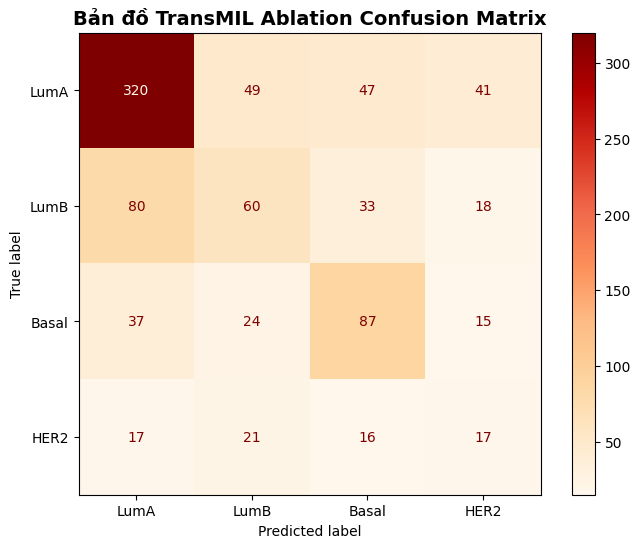

In [6]:
if len(valid_pids) > 0:
    cm = confusion_matrix(best_global_labels, best_global_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LumA', 'LumB', 'Basal', 'HER2'])
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='OrRd', ax=ax, values_format='d') # Màu đỏ lửa tượng trưng cho Ablation
    plt.title('Bản đồ TransMIL Ablation Confusion Matrix', fontsize=14, fontweight='bold')
    plt.show()